# Coffee Consumption and Health Analysis

## Programming for Data Analytics Group Project

### Dataset:
Synthetic Coffee Health Dataset (Kaggle)
https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset

# Coffee Consumption and Health Analysis

This project investigates the relationship between coffee consumption and several health indicators using a global coffee health dataset obtained from Kaggle. Various statistical techniques including correlation analysis, regression analysis, and T-tests are used to identify patterns and generate 
actionable insights.

# Research Questions

RQ1: Is there a relationship between coffee intake and sleep duration?

RQ2: Is there a relationship between caffeine intake and heart rate?

RQ3: Is there a relationship between coffee intake and BMI?

RQ4: Is there a relationship between coffee intake and physical activity levels?

RQ5: Do smokers and non-smokers differ in coffee consumption?

RQ6: Do males and females differ in coffee consumption?

# Dataset Description

This project uses the Global Coffee Health Dataset obtained from Kaggle. The dataset contains 10,000 records and multiple demographic, lifestyle, and health-related attributes.

The dataset was selected because it contains both numerical and categorical variables, allowing the application of multiple data analytics techniques including data preprocessing, visualization, correlation analysis, regression analysis, and hypothesis testing.

# Methodology

The following analytical techniques were used:

1. Data Cleaning and Preprocessing
2. Exploratory Data Analysis (EDA)
3. Correlation Analysis
4. Simple Linear Regression
5. Independent Sample T-Test

These techniques were selected to identify relationships between coffee consumption and various health indicators.

# Data Preprocessing

# Data Loading

The dataset was loaded into a Pandas DataFrame for analysis. The dataset contains demographic, lifestyle, and health-related information for 10,000 participants.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import csv
with open(r'D:\uni\sem vi\pda\data\fyp\synthetic_coffee_health_10000.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile)

    print(type(reader))
    print(reader.fieldnames)

<class 'csv.DictReader'>
['ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Health_Issues', 'Occupation', 'Smoking', 'Alcohol_Consumption']


In [3]:
with open(r'D:\uni\sem vi\pda\data\fyp\synthetic_coffee_health_10000.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile)

    rows = 101
    for row in reader:
        rows -= 1
        if (rows > 0):
            print(row)
        else:
            break

{'ID': '1', 'Age': '40', 'Gender': 'Male', 'Country': 'Germany', 'Coffee_Intake': '3.5', 'Caffeine_mg': '328.1', 'Sleep_Hours': '7.5', 'Sleep_Quality': 'Good', 'BMI': '24.9', 'Heart_Rate': '78', 'Stress_Level': 'Low', 'Physical_Activity_Hours': '14.5', 'Health_Issues': 'None', 'Occupation': 'Other', 'Smoking': '0', 'Alcohol_Consumption': '0'}
{'ID': '2', 'Age': '33', 'Gender': 'Male', 'Country': 'Germany', 'Coffee_Intake': '1.0', 'Caffeine_mg': '94.1', 'Sleep_Hours': '6.2', 'Sleep_Quality': 'Good', 'BMI': '20.0', 'Heart_Rate': '67', 'Stress_Level': 'Low', 'Physical_Activity_Hours': '11.0', 'Health_Issues': 'None', 'Occupation': 'Service', 'Smoking': '0', 'Alcohol_Consumption': '0'}
{'ID': '3', 'Age': '42', 'Gender': 'Male', 'Country': 'Brazil', 'Coffee_Intake': '5.3', 'Caffeine_mg': '503.7', 'Sleep_Hours': '5.9', 'Sleep_Quality': 'Fair', 'BMI': '22.7', 'Heart_Rate': '59', 'Stress_Level': 'Medium', 'Physical_Activity_Hours': '11.2', 'Health_Issues': 'Mild', 'Occupation': 'Office', 'Smok

In [4]:
pd.set_option('display.max_column', None)
pd.set_option('display.max_row', None)
df = pd.read_csv(r'D:\uni\sem vi\pda\data\fyp\synthetic_coffee_health_10000.csv')

In [5]:
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [6]:
df.tail()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0
9999,10000,42,Female,Brazil,2.9,277.5,6.4,Good,28.1,72,Low,9.8,NaN,Student,1,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [8]:
df.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


In [9]:
df.isnull().sum()

ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
Smoking                       0
Alcohol_Consumption           0
dtype: int64

## Interpretation: Missing Value Analysis

The missing value analysis revealed that the Health_Issues attribute contained 5,941 missing values while all other attributes contained complete records.

Further investigation suggested that these missing values likely represent participants without any reported health issues. Therefore, the missing values were replaced with "None" to improve data consistency while preserving all observations.

In [10]:
df['Health_Issues'].value_counts(dropna=False)

Health_Issues
NaN         5941
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64

In [11]:
df['Health_Issues'] = df['Health_Issues'].fillna('None')

In [12]:
df['Health_Issues'].value_counts(dropna=False)

Health_Issues
None        5941
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

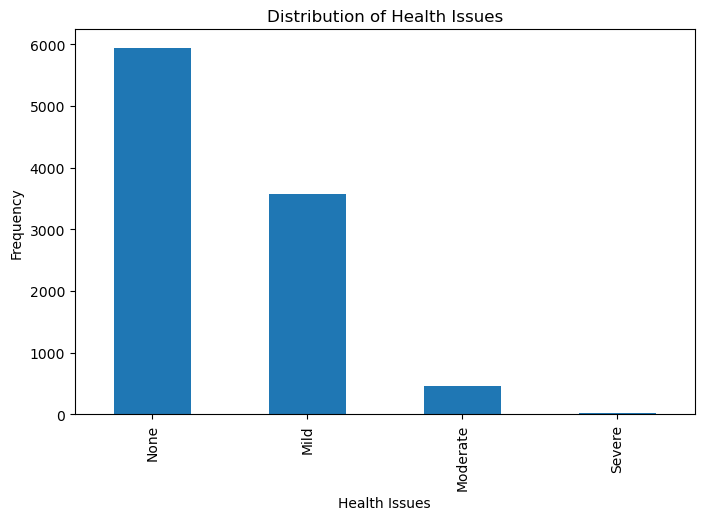

In [13]:
plt.figure(figsize=(8,5))

df['Health_Issues'].value_counts().plot(kind='bar')

plt.title('Distribution of Health Issues')
plt.xlabel('Health Issues')
plt.ylabel('Frequency')

plt.show()

## Interpretation: Distribution of Health Issues

The bar chart shows the distribution of health issues among participants in the dataset.

The majority of participants (5,941 individuals) reported no health issues, indicating that most observations represent a generally healthy population. Mild health issues were the second most common category with 3,579 records, while moderate and severe health issues were relatively rare, accounting for only 463 and 17 records respectively.

This distribution suggests that severe health conditions are uncommon within the dataset and that the majority of participants either have no reported health issues or only mild conditions.

# Correlation Analysis

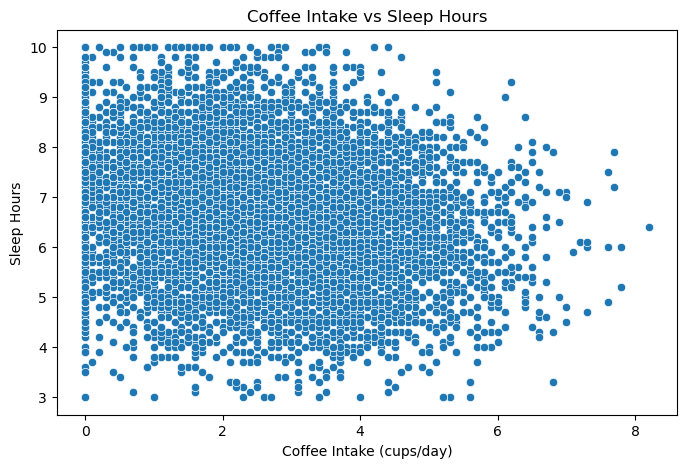

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Coffee_Intake',
    y='Sleep_Hours',
    data=df
)

plt.title('Coffee Intake vs Sleep Hours')
plt.xlabel('Coffee Intake (cups/day)')
plt.ylabel('Sleep Hours')

plt.show()

In [15]:
corr = df['Coffee_Intake'].corr(df['Sleep_Hours'])

print("Correlation:", corr)

Correlation: -0.19029074040177743


## Interpretation: Coffee Intake vs Sleep Hours

The scatter plot illustrates the relationship between coffee consumption and sleep duration.

The correlation coefficient was -0.1903, indicating a weak negative relationship between the variables. This suggests that individuals who consume more coffee tend to obtain slightly fewer hours of sleep.

Although the relationship is not strong, the result supports the commonly accepted understanding that increased caffeine consumption may contribute to reduced sleep duration.

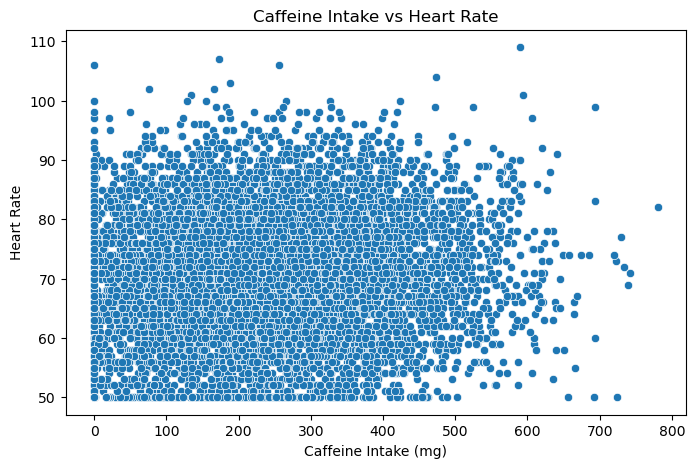

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Caffeine_mg',
    y='Heart_Rate',
    data=df
)

plt.title('Caffeine Intake vs Heart Rate')
plt.xlabel('Caffeine Intake (mg)')
plt.ylabel('Heart Rate')

plt.show()

In [17]:
corr = df['Caffeine_mg'].corr(df['Heart_Rate'])

print("Correlation:", corr)

Correlation: 0.06002704637031944


## Interpretation: Caffeine Intake vs Heart Rate

The scatter plot examines the relationship between caffeine intake and heart rate.

The correlation coefficient was 0.0600, indicating a very weak positive relationship. This suggests that as caffeine intake increases, heart rate may increase slightly; however, the relationship is extremely weak.

Therefore, caffeine intake does not appear to be a strong predictor of heart rate within this dataset.

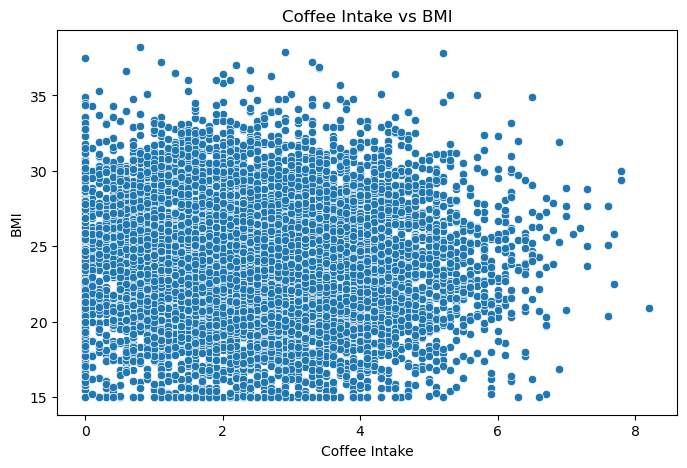

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Coffee_Intake',
    y='BMI',
    data=df
)

plt.title('Coffee Intake vs BMI')
plt.xlabel('Coffee Intake')
plt.ylabel('BMI')

plt.show()

In [19]:
corr = df['Coffee_Intake'].corr(df['BMI'])

print("Correlation:", corr)

Correlation: -0.008329786503644437


## Interpretation: Coffee Intake vs BMI

The relationship between coffee intake and BMI was examined using a scatter plot and correlation analysis.

The correlation coefficient was -0.0083, which is extremely close to zero. This indicates that there is virtually no relationship between coffee consumption and BMI.

The findings suggest that coffee intake alone does not significantly influence body mass index and that other factors such as diet, exercise, and lifestyle habits may play a more important role.

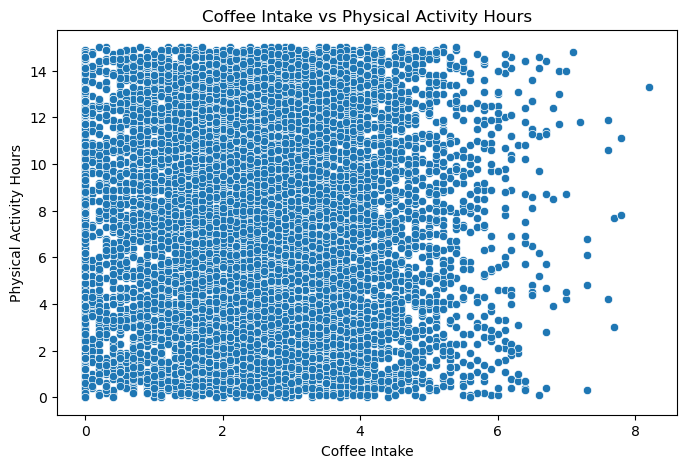

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Coffee_Intake',
    y='Physical_Activity_Hours',
    data=df
)

plt.title('Coffee Intake vs Physical Activity Hours')
plt.xlabel('Coffee Intake')
plt.ylabel('Physical Activity Hours')

plt.show()

In [21]:
corr = df['Coffee_Intake'].corr(df['Physical_Activity_Hours'])

print("Correlation:", corr)

Correlation: 0.004781596896096644


## Interpretation: Coffee Intake vs Physical Activity Hours

The scatter plot was used to explore the relationship between coffee intake and physical activity hours.

The correlation coefficient was 0.0048, indicating almost no relationship between the two variables.

This suggests that coffee consumption does not appear to influence the amount of physical activity performed by participants in the dataset.

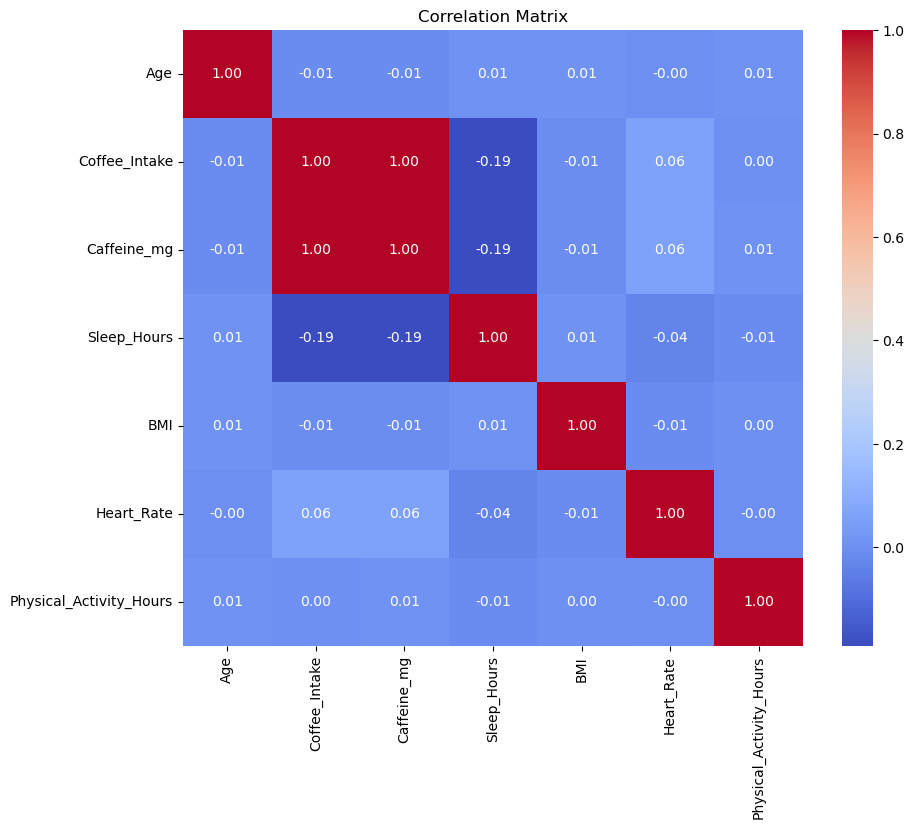

In [22]:
numerical_cols = [
    'Age',
    'Coffee_Intake',
    'Caffeine_mg',
    'Sleep_Hours',
    'BMI',
    'Heart_Rate',
    'Physical_Activity_Hours'
]

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

## Interpretation: Correlation Matrix Heatmap

The correlation matrix provides an overall summary of the relationships among numerical variables in the dataset.

The strongest positive correlation was observed between Coffee_Intake and Caffeine_mg (r = 0.9998), indicating an almost perfect positive relationship. This result is expected because caffeine intake increases proportionally with coffee consumption.

Sleep_Hours showed weak negative correlations with both Coffee_Intake (r = -0.1903) and Caffeine_mg (r = -0.1905), suggesting that higher coffee and caffeine consumption are associated with reduced sleep duration.

Most other variable pairs exhibited correlation values close to zero, indicating little or no meaningful linear relationship.

In [23]:
corr_matrix = df[
    ['Age',
     'Coffee_Intake',
     'Caffeine_mg',
     'Sleep_Hours',
     'BMI',
     'Heart_Rate',
     'Physical_Activity_Hours']
].corr()

print(corr_matrix)

                              Age  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
Age                      1.000000      -0.012155    -0.011797     0.005010   
Coffee_Intake           -0.012155       1.000000     0.999814    -0.190291   
Caffeine_mg             -0.011797       0.999814     1.000000    -0.190493   
Sleep_Hours              0.005010      -0.190291    -0.190493     1.000000   
BMI                      0.008627      -0.008330    -0.008706     0.008463   
Heart_Rate              -0.000197       0.060123     0.060027    -0.036219   
Physical_Activity_Hours  0.005931       0.004782     0.005026    -0.011228   

                              BMI  Heart_Rate  Physical_Activity_Hours  
Age                      0.008627   -0.000197                 0.005931  
Coffee_Intake           -0.008330    0.060123                 0.004782  
Caffeine_mg             -0.008706    0.060027                 0.005026  
Sleep_Hours              0.008463   -0.036219                -0.011228  
BMI       

## Observation

The numerical correlation matrix confirms the relationships visualized in the heatmap. The strongest relationship was observed between Coffee_Intake and Caffeine_mg, while most other variables exhibited weak or negligible correlations.

# Regression Analysis

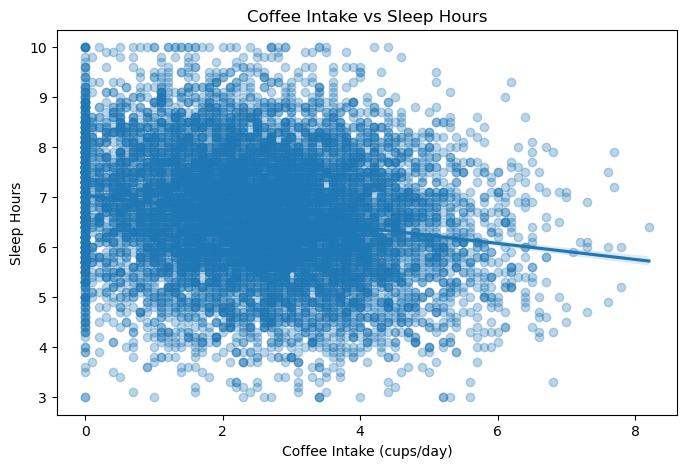

In [24]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='Coffee_Intake',
    y='Sleep_Hours',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title('Coffee Intake vs Sleep Hours')
plt.xlabel('Coffee Intake (cups/day)')
plt.ylabel('Sleep Hours')

plt.show()

## Interpretation: Coffee Intake vs Sleep Hours

The regression line displays a downward trend, indicating that sleep duration tends to decrease as coffee consumption increases.

This finding is consistent with the correlation analysis, which showed a weak negative relationship between Coffee_Intake and Sleep_Hours.

Although the effect is not strong, the model suggests that increased coffee consumption may contribute to reduced sleeping duration.

<Axes: xlabel='Caffeine_mg', ylabel='Sleep_Hours'>

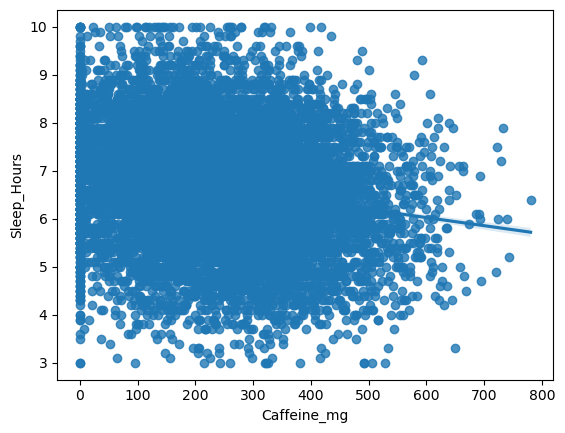

In [25]:
sns.regplot(
    x='Caffeine_mg',
    y='Sleep_Hours',
    data=df
)

## Interpretation: Caffeine Intake vs Sleep Hours

The regression analysis shows a negative relationship between caffeine intake and sleep duration.

The downward slope indicates that participants with higher caffeine intake generally report fewer hours of sleep.

This result further supports the findings from the correlation analysis and suggests that excessive caffeine consumption may negatively affect sleep patterns.

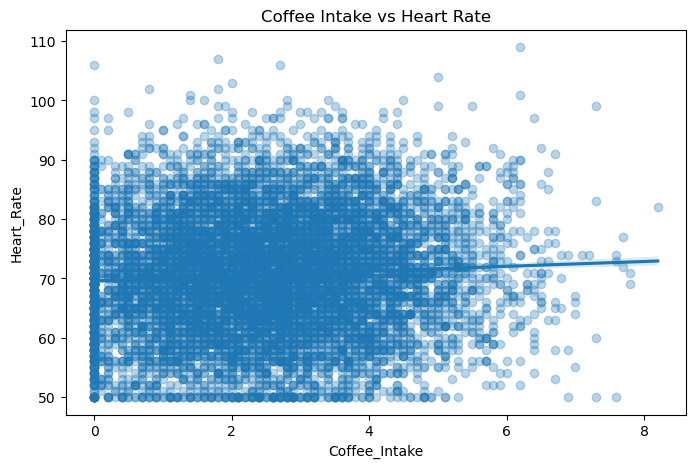

In [26]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='Coffee_Intake',
    y='Heart_Rate',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title('Coffee Intake vs Heart Rate')

plt.show()

## Interpretation: Coffee Intake vs Heart Rate

The regression line displays a slight upward trend, indicating a positive relationship between coffee consumption and heart rate.

However, the slope is nearly flat, suggesting that the effect is minimal. This observation is consistent with the weak correlation coefficient obtained earlier.

Therefore, coffee consumption appears to have only a limited impact on heart rate in this dataset.

# T-Test Analysis

A significance level of α = 0.05 was used for all hypothesis tests.

Decision Rule:

- If p-value < 0.05, reject H₀.
- If p-value ≥ 0.05, fail to reject H₀.

## Hypothesis

H₀: There is no significant difference in coffee consumption between smokers and non-smokers.

H₁: There is a significant difference in coffee consumption between smokers and non-smokers.

In [27]:
from scipy.stats import ttest_ind

smokers = df[df['Smoking'] == 1]['Coffee_Intake']
nonsmokers = df[df['Smoking'] == 0]['Coffee_Intake']

t_stat, p_value = ttest_ind(smokers, nonsmokers)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.0835483162993274
P-value: 0.278591246643735


## Interpretation: T-Test: Smokers vs Non-Smokers

An independent samples T-test was conducted to determine whether there is a significant difference in coffee consumption between smokers and non-smokers.

The analysis produced a T-statistic of 1.0835 and a P-value of 0.2786.

At a significance level of α = 0.05, the P-value is greater than α (0.2786 > 0.05). Therefore, the null hypothesis (H₀) cannot be rejected.

This indicates that there is insufficient statistical evidence to conclude that smokers and non-smokers differ significantly in their coffee consumption habits.

The result suggests that smoking status does not appear to be a major factor influencing coffee intake within this dataset.

## Hypothesis

H₀: There is no significant difference in coffee consumption between males and females.

H₁: There is a significant difference in coffee consumption between males and females.

In [28]:
male = df[df['Gender'] == 'Male']['Coffee_Intake']
female = df[df['Gender'] == 'Female']['Coffee_Intake']

t_stat, p_value = ttest_ind(male, female)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.8353588848651448
P-value: 0.4035360950966263


## Interpretation: T-Test: Male vs Female

An independent samples T-test was performed to determine whether there is a significant difference in coffee consumption between male and female participants.

The analysis produced a T-statistic of 0.8354 and a P-value of 0.4035.

At a significance level of α = 0.05, the P-value is greater than α (0.4035 > 0.05). Therefore, the null hypothesis (H₀) cannot be rejected.

This indicates that there is insufficient statistical evidence to conclude that coffee consumption differs significantly between male and female participants.

The findings suggest that coffee consumption patterns are generally similar across genders within this dataset.

# Conclusion

This study examined the relationship between coffee consumption and various health indicators using correlation analysis, regression analysis, and hypothesis testing.

The results revealed weak negative relationships between coffee consumption, caffeine intake, and sleep duration, suggesting that increased caffeine consumption may contribute to reduced sleep. However, coffee consumption showed little influence on heart rate, BMI, or physical activity levels.

Furthermore, independent samples T-tests were conducted to compare coffee consumption between smokers and non-smokers as well as between male and female participants. In both cases, the null hypothesis could not be rejected at a significance level of 0.05, indicating that there is insufficient statistical evidence to conclude that coffee consumption differs significantly between these groups.

Overall, the findings suggest that sleep duration is the health factor most noticeably associated with coffee and caffeine consumption within this dataset. These findings highlight the importance of responsible caffeine consumption, particularly for individuals seeking to maintain healthy sleeping habits.

The study demonstrates how data analytics techniques can be used to identify meaningful relationships and support evidence-based decision making in health-related datasets.

# References

Kaggle. (2025). Global Coffee Health Dataset. Retrieved from:
https://www.kaggle.com/
Python Software Foundation. Python Programming Language.

McKinney, W. (2022). Python for Data Analysis. O'Reilly Media.